# Proyecto_01

|                |   |
:----------------|---|
| **Fecha**      |  21 septiembre 2026 |

| Alumno | Expediente |
|--------|------------|
|     Claudio Alejo Encarnación Martínez   |      750597      |
|        |            |
|        |            |

## Objetivos

### Generales
Predecir e interpretar el desempeño en el examen de estudiantes (`Exam_Score`) a partir de factores académicos, personales, familiares y escolares, mediante la comparación de tres especificaciones de regresión (lineal, polinomial y con interacciones) ajustadas en cuatro versiones (sin penalización, Ridge, Lasso y ElasticNet), para identificar qué especificación representa mejor las relaciones presentes en los datos, qué método de regularización generaliza mejor y qué factores presentan mayor asociación predictiva con el desempeño.

### Específicos
1. **Analizar el conjunto de datos** `StudentPerformanceFactors.csv` en cuanto a su origen, contenido, calidad y estructura, identificando valores faltantes, valores fuera de rango, tipos de variables y posibles transformaciones necesarias para su uso en modelos de regresión.

2. **Construir un pipeline de preprocesamiento** que incluya limpieza de datos, imputación de valores faltantes, codificación de variables categóricas (ordinales y binarias), escalamiento de variables numéricas y partición de entrenamiento y prueba, garantizando que todas las transformaciones se ajusten únicamente con los datos de entrenamiento.

3. **Definir tres especificaciones de regresión**: una lineal múltiple sin interacciones, una polinomial con términos seleccionados y una con interacciones justificadas entre factores, cada una en cuatro versiones: sin penalización (OLS), Ridge, Lasso y ElasticNet.

4. **Seleccionar los hiperparámetros de penalización** de las versiones Ridge, Lasso y ElasticNet mediante validación cruzada de 5 folds con `GridSearchCV`, usando R² como métrica de optimización.

5. **Ajustar y comparar los doce modelos resultantes** mediante métricas de desempeño (R², RMSE) en entrenamiento y prueba, con visualizaciones que permitan identificar diferencias entre especificaciones y entre versiones de penalización.

6. **Realizar un análisis de residuos** sobre el modelo lineal sin penalización para evaluar los seis supuestos clásicos de la regresión: no linealidad, correlación en errores, varianza no constante, outliers, puntos palanca y colinealidad, y proponer las transformaciones pertinentes a partir de los resultados.

7. **Analizar la significancia de los factores** en el modelo lineal sin penalización, mediante pruebas t individuales y la prueba F global, identificando qué factores se asocian significativamente con `Exam_Score`, y reportando el signo, magnitud e intervalos de confianza de los coeficientes estimados.

8. **Comparar los resultados entre las tres especificaciones y las cuatro versiones** para determinar qué combinación logra el mejor equilibrio entre capacidad predictiva, interpretabilidad y estabilidad, y **concluir respecto al objetivo general** sobre qué factores y qué tipo de modelo describen mejor el desempeño en el examen.

## Marco Teórico

### Regresión lineal

La regresión lineal es un método de aprendizaje supervisado utilizado para predecir una variable cuantitativa a partir de una o más variables predictoras. En este proyecto, la variable respuesta será la calificación obtenida en el examen, mientras que las variables predictoras serán los factores disponibles en el conjunto de datos *Student Performance Factor*.

En su forma múltiple, el modelo se expresa como:

$$
Y_i = \beta_0 + \beta_1X_{i1} + \beta_2X_{i2} + \cdots + \beta_pX_{ip} + \varepsilon_i
$$

donde:

- $Y_i$ es la calificación observada del estudiante $i$.
- $\beta_0$ es el intercepto.
- $\beta_j$ representa el cambio promedio esperado en $Y$ asociado con un incremento de una unidad en $X_j$, manteniendo constantes los demás factores.
- $\varepsilon_i$ representa el error aleatorio no explicado por el modelo.

Los coeficientes se estiman habitualmente mediante mínimos cuadrados ordinarios (OLS), que minimizan la suma de cuadrados de los residuos:

$$
RSS = \sum_{i=1}^{n}(y_i-\hat{y}_i)^2
$$

El residuo $e_i=y_i-\hat{y}_i$ es la diferencia entre la calificación observada y la predicha. Un modelo con residuos pequeños tiende a ajustarse mejor a los datos de entrenamiento, aunque el desempeño debe verificarse también con datos no utilizados durante el ajuste.

Para evaluar el ajuste pueden emplearse métricas como el error cuadrático medio (MSE), la raíz del error cuadrático medio (RMSE), el error absoluto medio (MAE) y el coeficiente de determinación $R^2$. El valor de $R^2$ representa la proporción de variabilidad de la respuesta explicada por el modelo; sin embargo, debe complementarse con métricas de prueba o validación cruzada para evitar conclusiones basadas únicamente en el entrenamiento.

### Regresión polinomial

La regresión polinomial permite modelar relaciones no lineales entre una variable predictora y la respuesta, manteniendo un modelo lineal respecto a sus coeficientes. Por ejemplo, un modelo cuadrático para una variable $X$ se expresa como:

$$
Y_i = \beta_0 + \beta_1X_i + \beta_2X_i^2 + \varepsilon_i
$$

De forma general, un polinomio de grado $d$ es:

$$
Y_i = \beta_0 + \beta_1X_i + \beta_2X_i^2 + \cdots + \beta_dX_i^d + \varepsilon_i
$$

Aunque la relación entre $X$ y $Y$ puede ser curva, el modelo sigue siendo lineal porque los parámetros $\beta_j$ se estiman linealmente. Este enfoque es útil si los gráficos de dispersión o de residuos muestran curvatura que una regresión lineal simple no puede representar.

Un grado polinomial alto aumenta la flexibilidad del modelo, pero también el riesgo de sobreajuste: el modelo puede aprender ruido específico de los datos de entrenamiento y generalizar mal. Por ello, el grado debe elegirse mediante validación cruzada y comparando el error de prueba.

### Interacción de factores

Existe una interacción cuando el efecto de una variable predictora sobre la calificación depende del nivel de otra variable. Por ejemplo, el efecto de las horas de estudio podría ser distinto según las sesiones de tutoria del estudiante o el acceso a recursos educativos.

Para dos predictores $X_1$ y $X_2$, un modelo con interacción es:

$$
Y_i = \beta_0 + \beta_1X_{i1} + \beta_2X_{i2} + \beta_3(X_{i1}X_{i2}) + \varepsilon_i
$$

El término $X_1X_2$ representa la interacción. Al reorganizar el modelo se obtiene:

$$
Y_i = \beta_0 + (\beta_1+\beta_3X_{i2})X_{i1} + \beta_2X_{i2} + \varepsilon_i
$$

Por tanto, el efecto de $X_1$ deja de ser constante: depende de $X_2$. Si el coeficiente $\beta_3$ es relevante, incluir solamente los efectos principales puede producir una representación incompleta de la relación entre los factores y la calificación.

Debe respetarse el principio jerárquico: si se incorpora una interacción $X_1X_2$, también deben conservarse $X_1$ y $X_2$ en el modelo, aun cuando alguno de sus coeficientes individuales no resulte significativo.

### Significancia de factores

La significancia estadística permite evaluar si existe evidencia de que un predictor tiene asociación con la respuesta, después de controlar por los demás predictores incluidos en el modelo.

Para cada factor se plantea, usualmente, la prueba de hipótesis:

$$
H_0:\beta_j=0
$$

$$
H_a:\beta_j\neq0
$$

El estadístico de prueba es:

$$
t = \frac{\hat{\beta}_j}{SE(\hat{\beta}_j)}
$$

donde $SE(\hat{\beta}_j)$ es el error estándar del coeficiente estimado. A partir de este estadístico se obtiene el *p-value*. Un *p-value* pequeño, comúnmente menor que $\alpha=0.05$, proporciona evidencia para rechazar $H_0$ y concluir que el factor está asociado con la calificación dentro del modelo planteado.

La significancia no equivale a causalidad ni garantiza una mejora importante en la predicción. Un factor puede tener un *p-value* pequeño y un efecto práctico reducido; también puede parecer no significativo cuando existe colinealidad con otros predictores. Por ello, la interpretación debe integrar el tamaño y signo del coeficiente, los intervalos de confianza, el conocimiento del problema y el desempeño predictivo.

La significancia global del modelo puede evaluarse mediante una prueba $F$, cuya hipótesis nula establece que todos los coeficientes de pendiente son iguales a cero:

$$
H_0:\beta_1=\beta_2=\cdots=\beta_p=0
$$

### Regularización

La regularización modifica la función de costo de mínimos cuadrados al agregar una penalización sobre el tamaño de los coeficientes. Su objetivo es disminuir la varianza del modelo, reducir el sobreajuste y tratar de forma más estable conjuntos con variables correlacionadas o con muchas características.

Antes de ajustar modelos penalizados, las variables numéricas deben estandarizarse, ya que las penalizaciones dependen de la escala de los coeficientes. La selección del hiperparámetro de penalización debe realizarse con validación cruzada sobre el conjunto de entrenamiento.

#### Ridge

La regresión Ridge utiliza una penalización $L2$:

$$
\min_{\beta}\left\{
RSS+\lambda\sum_{j=1}^{p}\beta_j^2
\right\}
$$

El parámetro $\lambda\geq0$ controla la intensidad de la penalización. Si $\lambda=0$, el modelo equivale a mínimos cuadrados ordinarios. Conforme $\lambda$ aumenta, los coeficientes se reducen hacia cero, pero normalmente no se vuelven exactamente cero.

Ridge es especialmente útil ante multicolinealidad, ya que estabiliza los coeficientes de predictores correlacionados. Conserva todas las variables, por lo que privilegia la predicción y la estabilidad sobre la selección explícita de factores.

#### Lasso

La regresión Lasso utiliza una penalización $L1$:

$$
\min_{\beta}\left\{
RSS+\lambda\sum_{j=1}^{p}|\beta_j|
\right\}
$$

A diferencia de Ridge, Lasso puede llevar algunos coeficientes exactamente a cero. Por ello realiza selección automática de variables y genera modelos más escasos e interpretables.

Lasso puede ser conveniente si se espera que solo una parte de los factores disponibles influya de forma relevante en el resultado del examen. No obstante, cuando varios predictores están altamente correlacionados, puede conservar uno y excluir otros de manera inestable.

#### ElasticNet

ElasticNet combina las penalizaciones Ridge y Lasso:

$$
\min_{\beta}\left\{
RSS+\lambda\left[
(1-\alpha)\frac{1}{2}\sum_{j=1}^{p}\beta_j^2+
\alpha\sum_{j=1}^{p}|\beta_j|
\right]
\right\}
$$

donde $\lambda$ controla la intensidad total de la penalización y $\alpha$ define la mezcla:

- $\alpha=0$: comportamiento equivalente a Ridge.
- $\alpha=1$: comportamiento equivalente a Lasso.
- $0<\alpha<1$: combinación de ambas penalizaciones.

ElasticNet es adecuado cuando existen grupos de variables correlacionadas, situación posible en factores académicos y socioeconómicos. Puede seleccionar variables, como Lasso, y al mismo tiempo distribuir de manera más estable el efecto entre predictores relacionados, como Ridge.

### Seis errores comunes en una regresión

1. **No linealidad entre predictores y respuesta.**  
   Ocurre cuando la relación real presenta curvatura y se ajusta únicamente una recta. Puede detectarse mediante gráficos de residuos; un patrón sistemático sugiere que el modelo lineal es insuficiente. Como respuesta, pueden evaluarse transformaciones, términos polinomiales o interacciones justificadas.

2. **Correlación entre términos de error.**  
   Los errores deberían ser independientes. Si las observaciones están ordenadas en el tiempo, pertenecen al mismo grupo o contienen registros relacionados, los errores pueden correlacionarse. Esto afecta los errores estándar, intervalos de confianza y pruebas de hipótesis.

3. **Varianza no constante de los errores.**  
   La heterocedasticidad ocurre cuando la dispersión de los residuos cambia con el nivel de las predicciones. Puede observarse como una forma de embudo en el gráfico de residuos. Es posible considerar transformaciones de la respuesta, métodos ponderados o estimadores robustos.

4. **Valores atípicos (*outliers*).**  
   Son observaciones con una respuesta muy alejada de lo predicho por el modelo. Pueden deberse a errores de captura, casos excepcionales o variables relevantes ausentes. Deben revisarse con residuos estudentizados, pero no eliminarse automáticamente: primero debe verificarse su origen.

5. **Puntos de alta palanca (*high leverage*).**  
   Son observaciones con valores inusuales en los predictores y que pueden modificar de manera importante la recta o el hiperplano de regresión. Se analizan mediante estadísticas de palanca y medidas de influencia, como la distancia de Cook.

6. **Colinealidad o multicolinealidad.**  
   Se presenta cuando dos o más predictores contienen información muy semejante. Dificulta separar su efecto individual, incrementa los errores estándar y vuelve inestables los coeficientes. Puede detectarse mediante correlaciones y el factor de inflación de varianza (VIF). Ridge y ElasticNet son alternativas útiles para mitigar sus efectos.

### Tema elegido para el proyecto

El tema del proyecto se define como la **predicción e interpretación del desempeño en examen de estudiantes mediante modelos de regresión regularizados**. El objetivo, como ya se menciono, es estimar la calificación de examen a partir de los 29 factores restantes del conjunto de datos *Student Performance Factor*, desarrollando un pipeline completo de preparación, modelado, evaluación e interpretación.

Se propone comparar tres especificaciones de regresión:

1. **Modelo lineal múltiple:** incorpora los factores originales disponibles.
2. **Modelo polinomial:** incorpora términos polinomiales seleccionados para representar relaciones no lineales plausibles.
3. **Modelo con interacciones:** incorpora interacciones justificadas entre factores académicos, de hábitos y de contexto del estudiante.

Cada especificación se ajustará en cuatro versiones:

| Versión | Método |
|---|---|
| Base | Regresión lineal sin penalización |
| Ridge | Penalización $L2$ |
| Lasso | Penalización $L1$ |
| ElasticNet | Penalización combinada $L1$ y $L2$ |

En total, se compararán doce modelos. El pipeline deberá incluir limpieza de datos, tratamiento de valores faltantes y variables categóricas, partición de entrenamiento y prueba, estandarización dentro del pipeline, ajuste de hiperparámetros mediante validación cruzada y evaluación final con métricas como RMSE, MAE y $R^2$.

La comparación permitirá responder tres preguntas centrales: qué especificación representa mejor las relaciones presentes en los datos, qué método de regularización logra la mejor capacidad de generalización y cuáles factores presentan mayor asociación predictiva con el desempeño en el examen.

## Análisis del Dataset

### Análisis
El conjunto de datos **StudentPerformanceFactors.csv** proviene de la plataforma [Kaggle](https://www.kaggle.com/datasets/fares279/student-performance-factors), donde se publica para analizar los factores académicos, personales, familiares y escolares asociados con el desempeño estudiantil. El archivo contiene 6,607 muestras y 20 variables: 19 predictores y la variable objetivo **Exam_Score**. Cada muestra representa a un estudiante y reúne información sobre sus hábitos de estudio, asistencia, resultados previos, descanso, tutorías, actividad física, motivación, acceso a internet y recursos, contexto familiar, características escolares y variables demográficas. De esta forma, las muestras permiten observar cómo la combinación de condiciones académicas, sociales y personales se relaciona con la calificación final del examen.

El análisis busca construir modelos de regresión capaces de predecir **Exam_Score** y comparar qué factores aportan mayor capacidad predictiva. Las variables numéricas son **Hours_Studied**, **Attendance**, **Sleep_Hours**, **Previous_Scores**, **Tutoring_Sessions** y **Physical_Activity**; estas se estandarizarán mediante **StandardScaler** de **sklearn** para que tengan una escala comparable. Este paso es especialmente importante en Ridge, Lasso y ElasticNet, pues sus penalizaciones dependen de la magnitud de los coeficientes y podrían penalizar de manera desigual a variables medidas en escalas distintas.

Las variables binarias **Extracurricular_Activities**, **Internet_Access**, **School_Type**, **Learning_Disabilities**, **Gender** y **Peer_Influence** se transformarán mediante *one-hot encoding*. Las variables ordinales **Parental_Involvement**, **Access_to_Resources**, **Motivation_Level**, **Family_Income**, **Teacher_Quality**, **Parental_Education_Level** y **Distance_from_Home** se codificarán mediante *ordinal encoding*, respetando un orden definido. Por ejemplo, `Low < Medium < High`, `High School < College < Postgraduate` y `Near < Moderate < Far`.

Al realizar la regresión, se espera que factores como **Previous_Scores**, **Attendance**, **Hours_Studied**, **Tutoring_Sessions**, **Access_to_Resources** y **Motivation_Level** se asocien positivamente con la calificación de examen, mientras que otros como **Learning_Disabilities** o **Extracurricular_Activities** tengan el efecto contrario. Sin embargo, el modelo permitirá cuantificar estas relaciones, identificar variables redundantes y comparar si la regularización mejora la generalización.

### Variables

| Variable | Tipo de variable | Definición | Valores esperados / categorías |
|---|---|---|---|
| `Hours_Studied` | Numérica | Horas de estudio por semana | 0 a 44 |
| `Attendance` | Numérica | Porcentaje de asistencia | 0 a 100 |
| `Parental_Involvement` | Categórica ordinal | Participación de los padres | `Low`, `Medium`, `High` |
| `Access_to_Resources` | Categórica ordinal | Acceso a recursos educativos | `Low`, `Medium`, `High` |
| `Extracurricular_Activities` | Categórica binaria | Participa en actividades extracurriculares | `No`, `Yes` |
| `Sleep_Hours` | Numérica | Horas promedio de sueño por noche | 4 a 10 |
| `Previous_Scores` | Numérica | Calificaciones previas | 50 a 100 |
| `Motivation_Level` | Categórica ordinal | Nivel de motivación | `Low`, `Medium`, `High` |
| `Internet_Access` | Categórica binaria | Disponibilidad de internet | `No`, `Yes` |
| `Tutoring_Sessions` | Numérica | Sesiones de tutoría por mes | 0 a 8 |
| `Family_Income` | Categórica ordinal | Nivel de ingreso familiar | `Low`, `Medium`, `High` |
| `Teacher_Quality` | Categórica ordinal | Calidad percibida del profesorado | `Low`, `Medium`, `High` |
| `School_Type` | Categórica binaria | Tipo de escuela | `Public`, `Private` |
| `Peer_Influence` | Categórica ordinal | Influencia de los pares | `Negative`, `Neutral`, `Positive` |
| `Physical_Activity` | Numérica | Horas de actividad física por semana | 0 a 6 |
| `Learning_Disabilities` | Categórica binaria | Presencia de discapacidad de aprendizaje | `No`, `Yes` |
| `Parental_Education_Level` | Categórica ordinal | Máximo nivel educativo de los padres | `High School`, `College`, `Postgraduate` |
| `Distance_from_Home` | Categórica ordinal | Distancia entre hogar y escuela | `Near`, `Moderate`, `Far` |
| `Gender` | Categórica binaria | Género del estudiante | `Female`, `Male` |
| `Exam_Score` | Numérica | Calificación final del examen; variable objetivo | 0 a 100 |

## Modelos

### Regresión lineal múltiple sin interacciones

### Justificación

El primer modelo propuesto es una **regresión lineal múltiple sin interacciones ni términos polinomiales**. Se elige como punto de partida porque:

- Es el modelo más simple e interpretable: cada coeficiente representa el cambio promedio esperado en `Exam_Score` ante un incremento de una unidad en el predictor, manteniendo constantes los demás.
- Permite evaluar si los 19 factores disponibles tienen una relación lineal con la calificación.
- Sirve como línea base para comparar con los modelos polinomial y con interacciones.
- Sus residuos permitirán diagnosticar si la linealidad es suficiente o si se requieren transformaciones.

Para el estudiante $i$, el modelo se plantea como:

$$
\text{Exam Score}_i = \beta_0 + \sum_{j=1}^{p} \beta_j X_{ij} + \varepsilon_i
$$

donde $X_{ij}$ representa cada uno de los factores incluidos. Los 19 predictores se incorporan así:

- **Numéricas (6):** `Hours_Studied`, `Attendance`, `Sleep_Hours`, `Previous_Scores`, `Tutoring_Sessions`, `Physical_Activity`. Entran directamente, estandarizadas con `StandardScaler`.
- **Ordinales (8):** `Parental_Involvement`, `Access_to_Resources`, `Motivation_Level`, `Family_Income`, `Teacher_Quality`, `Parental_Education_Level`, `Distance_from_Home`, `Peer_Influence`. Se codifican con `OrdinalEncoder` respetando su orden natural.
- **Binarias (5):** `Extracurricular_Activities`, `Internet_Access`, `School_Type`, `Learning_Disabilities`, `Gender`. Se codifican como 0/1 con `OrdinalEncoder`.

**No se incluyen interacciones ni términos cuadráticos.** Cualquier transformación adicional se justificará a partir del análisis de residuos.

### Versiones a comparar

| Versión | Método | Penalización |
|---|---|---|
| Base | `LinearRegression` | Ninguna |
| Ridge | `Ridge` | $L_2$ |
| Lasso | `Lasso` | $L_1$ |
| ElasticNet | `ElasticNet` | $L_1 + L_2$ |

Para Ridge, Lasso y ElasticNet, el hiperparámetro de penalización se seleccionará mediante validación cruzada de 5 folds sobre el conjunto de entrenamiento, usando `GridSearchCV` y `R²` como métrica.

### Transformaciones previstas

Se aplicarán las siguientes transformaciones dentro del pipeline:

1. **Imputación:** mediana para variables numéricas, moda para categóricas.
2. **Escalamiento:** `StandardScaler` para numéricas (obligatorio antes de Ridge, Lasso y ElasticNet).
3. **Codificación:** `OrdinalEncoder` para ordinales y binarias.

Si el análisis de residuos revela no linealidad, heterocedasticidad o colinealidad severa, se propondrán transformaciones adicionales.

### Resultados esperados

Se espera que `Previous_Scores`, `Attendance`, `Hours_Studied`, `Tutoring_Sessions`, `Access_to_Resources` y `Motivation_Level` se asocien positivamente con `Exam_Score`. Las versiones penalizadas podrían mejorar la generalización si existe sobreajuste o colinealidad. La comparación de $R^2$ en entrenamiento y prueba permitirá identificar si el modelo lineal simple es suficiente o si se necesita mayor flexibilidad.

### Librerias

In [34]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.preprocessing import StandardScaler, OneHotEncoder, OrdinalEncoder

### Carga de Datos

Se cargan los datos directamente del repostirio de Github del proyecto usando el 'archivo crudo' del dataset.

In [35]:
url = 'https://raw.githubusercontent.com/juanmoranerre/student-performance-regression/refs/heads/main/StudentPerformanceFactors.csv'
df = pd.read_csv(url)
df.head(5)

,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Previous_Scores,Motivation_Level,Internet_Access,Tutoring_Sessions,Family_Income,Teacher_Quality,School_Type,Peer_Influence,Physical_Activity,Learning_Disabilities,Parental_Education_Level,Distance_from_Home,Gender,Exam_Score
0,23.0,84.0,Low,High,No,7,73,Low,Yes,0.0,Low,Medium,Public,Positive,3.0,No,High School,Near,Male,67.0
1,19.0,64.0,Low,Medium,No,8,59,Low,Yes,NaN,Medium,Medium,Public,Negative,4.0,No,College,Moderate,Female,61.0
2,24.0,98.0,Medium,Medium,Yes,7,91,Medium,Yes,2.0,Medium,Medium,Public,Neutral,4.0,No,Postgraduate,Near,Male,74.0
3,29.0,89.0,Low,Medium,Yes,8,98,Medium,Yes,1.0,Medium,Medium,Public,Negative,4.0,No,High School,Moderate,Male,71.0
4,19.0,92.0,Medium,Medium,Yes,6,65,Medium,Yes,3.0,Medium,High,Public,Neutral,4.0,No,College,Near,Female,70.0


### Análisis Exploratorio de Datos

Previamente se realizo un análisis exploratorio para la realización del análisis del dataset. Sin embargo, a continuación se muestra un breve resumen del datset.

In [36]:
# Numero de filas y columnas
nrows, ncols = df.shape
print(f'El DataFrame tiene {nrows} filas y {ncols} columnas.')

# Tipos de datos y columnas
print('\nTipos de datos:')
print(df.dtypes)

El DataFrame tiene 6607 filas y 20 columnas.

Tipos de datos:
Hours_Studied                 float64
Attendance                    float64
Parental_Involvement              str
Access_to_Resources               str
Extracurricular_Activities        str
Sleep_Hours                     int64
Previous_Scores                 int64
Motivation_Level                  str
Internet_Access                   str
Tutoring_Sessions             float64
Family_Income                     str
Teacher_Quality                   str
School_Type                       str
Peer_Influence                    str
Physical_Activity             float64
Learning_Disabilities             str
Parental_Education_Level          str
Distance_from_Home                str
Gender                            str
Exam_Score                    float64
dtype: object


In [37]:
# Valores nulos
print('Valores nulos por columna:')
print(df.isnull().sum())


Valores nulos por columna:
Hours_Studied                  2
Attendance                     2
Parental_Involvement           1
Access_to_Resources            2
Extracurricular_Activities     2
Sleep_Hours                    0
Previous_Scores                0
Motivation_Level               1
Internet_Access                1
Tutoring_Sessions              1
Family_Income                  1
Teacher_Quality               79
School_Type                    2
Peer_Influence                 1
Physical_Activity              3
Learning_Disabilities          0
Parental_Education_Level      90
Distance_from_Home            68
Gender                         1
Exam_Score                     2
dtype: int64


In [38]:
# Valores Duplicados
print('Filas duplicadas:')
print(df.duplicated().sum())

Filas duplicadas:
0


## Limpieza de datos

In [39]:
# Limpieza de datos

# Valores fuera de rango → NaN
# Exam_Score debe estar entre 0 y 100
df.loc[(df['Exam_Score'] < 0) | (df['Exam_Score'] > 100), 'Exam_Score'] = np.nan

# Attendance debe estar entre 0 y 100
df.loc[(df['Attendance'] < 0) | (df['Attendance'] > 100), 'Attendance'] = np.nan

# Hours_Studied debe ser >= 0
df.loc[df['Hours_Studied'] < 0, 'Hours_Studied'] = np.nan

# Sleep_Hours debe estar entre 0 y 24
df.loc[(df['Sleep_Hours'] < 0) | (df['Sleep_Hours'] > 24), 'Sleep_Hours'] = np.nan

# Previous_Scores debe estar entre 0 y 100
df.loc[(df['Previous_Scores'] < 0) | (df['Previous_Scores'] > 100), 'Previous_Scores'] = np.nan

# Tutoring_Sessions debe ser >= 0
df.loc[df['Tutoring_Sessions'] < 0, 'Tutoring_Sessions'] = np.nan

# Physical_Activity debe ser >= 0
df.loc[df['Physical_Activity'] < 0, 'Physical_Activity'] = np.nan

# Eliminar filas sin variable objetivo (no se puede imputar el target)
df = df.dropna(subset=['Exam_Score'])

# Resetear índice
df = df.reset_index(drop=True)

# 4. Verificación
print(f"Filas después de limpieza: {df.shape[0]}")
print(f"Valores nulos restantes:\n{df.isnull().sum()}")

Filas después de limpieza: 6603
Valores nulos restantes:
Hours_Studied                  1
Attendance                     3
Parental_Involvement           1
Access_to_Resources            2
Extracurricular_Activities     2
Sleep_Hours                    0
Previous_Scores                0
Motivation_Level               1
Internet_Access                1
Tutoring_Sessions              1
Family_Income                  1
Teacher_Quality               79
School_Type                    2
Peer_Influence                 1
Physical_Activity              3
Learning_Disabilities          0
Parental_Education_Level      90
Distance_from_Home            68
Gender                         1
Exam_Score                     0
dtype: int64


## 1. Modelo inicial (lineal múltiple sin interacciones)

In [40]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OrdinalEncoder
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import Ridge, Lasso, ElasticNet
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.model_selection import GridSearchCV

### 1.1 Pipelines

In [41]:
# Definición de columnas
target_col = 'Exam_Score'

num_cols = ['Hours_Studied','Attendance','Sleep_Hours','Previous_Scores','Tutoring_Sessions','Physical_Activity']

ord_cols = ['Parental_Involvement','Access_to_Resources','Motivation_Level',
            'Family_Income','Teacher_Quality','Parental_Education_Level',
            'Distance_from_Home','Peer_Influence']

bin_cols = ['Extracurricular_Activities', 'Internet_Access', 'School_Type',
            'Learning_Disabilities', 'Gender']

# ==========================================
# Categorías ordenadas para OrdinalEncoder
# ==========================================
# Cada lista corresponde al orden de las columnas en ord_cols
ordinal_categories = [
    ['Low', 'Medium', 'High'],                    # Parental_Involvement
    ['Low', 'Medium', 'High'],                    # Access_to_Resources
    ['Low', 'Medium', 'High'],                    # Motivation_Level
    ['Low', 'Medium', 'High'],                    # Family_Income
    ['Low', 'Medium', 'High'],                    # Teacher_Quality
    ['High School', 'College', 'Postgraduate'],   # Parental_Education_Level
    ['Near', 'Moderate', 'Far'],                  # Distance_from_Home
    ['Negative', 'Neutral', 'Positive']           # Peer_Influence
]

# Categorías para binarias (orden alfabético o explícito)
# OrdinalEncoder las convierte a 0/1
binary_categories = [
    ['No', 'Yes'],      # Extracurricular_Activities
    ['No', 'Yes'],      # Internet_Access
    ['Public', 'Private'],  # School_Type
    ['No', 'Yes'],      # Learning_Disabilities
    ['Female', 'Male']  # Gender
]

# Transformadores
numerical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

ordinal_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OrdinalEncoder(categories=ordinal_categories,
                               handle_unknown='use_encoded_value',
                               unknown_value=-1))
])

binary_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OrdinalEncoder(categories=binary_categories,
                               handle_unknown='use_encoded_value',
                               unknown_value=-1))
])

# ColumnTransformer
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numerical_transformer, num_cols),
        ('ord', ordinal_transformer, ord_cols),
        ('bin', binary_transformer, bin_cols)
    ],
    remainder='drop'
)



In [42]:
# Pipeline completo (modelo 1)
pipeline_base = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', LinearRegression())
])


pipeline_ridge = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', Ridge(random_state=42))
])

pipeline_lasso = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', Lasso(random_state=42, max_iter=10000))
])

pipeline_enet = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', ElasticNet(random_state=42, max_iter=10000))
])

### 1.2 Análisis de residuos (modelo 1, OLS sin penalización)

In [43]:
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor
import statsmodels.stats.api as sms
from statsmodels.compat import lzip
import matplotlib.pyplot as plt
import numpy as np

In [44]:
# Ajustar preprocessor y transformar X_train
X = df.drop(columns=target_col)
y = df[target_col]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

#Ajustar el preprocessor solo con train
preprocessor.fit(X_train)
X_train_trans = preprocessor.transform(X_train)
X_test_trans = preprocessor.transform(X_test)

#Nombres de las columnas transformadas
feature_names = preprocessor.get_feature_names_out()
X_train_df = pd.DataFrame(X_train_trans, columns=feature_names, index=X_train.index)

#Agregar constante para statsmodels
X_train_const = sm.add_constant(X_train_df)

#Ajustar OLS con statsmodels
model = sm.OLS(y_train, X_train_const).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:             Exam_Score   R-squared:                       0.746
Model:                            OLS   Adj. R-squared:                  0.745
Method:                 Least Squares   F-statistic:                     812.0
Date:                Sun, 20 Sep 2026   Prob (F-statistic):               0.00
Time:                        22:22:38   Log-Likelihood:                -11022.
No. Observations:                5282   AIC:                         2.208e+04
Df Residuals:                    5262   BIC:                         2.222e+04
Df Model:                          19                                         
Covariance Type:            nonrobust                                         
                                      coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------------------
const     

#### 1.2.1 No linealidad

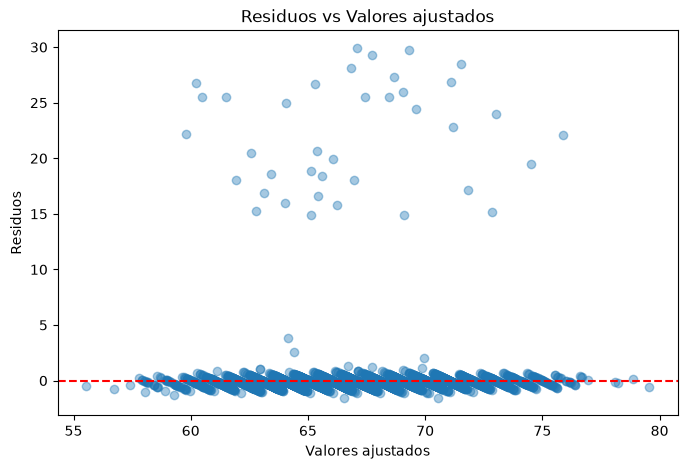

In [45]:
# Residuos vs valores ajustados
fitted = model.fittedvalues
residuals = model.resid

plt.figure(figsize=(8, 5))
plt.scatter(fitted, residuals, alpha=0.4)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel('Valores ajustados')
plt.ylabel('Residuos')
plt.title('Residuos vs Valores ajustados')
plt.show()

Según lo observado, habría que agregar términos polinomiales como transformación para atacar este problema. Esto se explorará más adelante en otros modelos.

#### 1.2.2 Correlación en errores

In [46]:
# Correlación entre residuos y variables independientes
correlations = {}
for column in X_train_df.columns:
    correlation = np.corrcoef(model.resid, X_train_df[column])[0, 1]
    correlations[column] = correlation
    print(f"Correlación entre residuos y {column}: {correlation:.4f}")

Correlación entre residuos y num__Hours_Studied: 0.0000
Correlación entre residuos y num__Attendance: 0.0000
Correlación entre residuos y num__Sleep_Hours: 0.0000
Correlación entre residuos y num__Previous_Scores: -0.0000
Correlación entre residuos y num__Tutoring_Sessions: -0.0000
Correlación entre residuos y num__Physical_Activity: 0.0000
Correlación entre residuos y ord__Parental_Involvement: -0.0000
Correlación entre residuos y ord__Access_to_Resources: -0.0000
Correlación entre residuos y ord__Motivation_Level: -0.0000
Correlación entre residuos y ord__Family_Income: -0.0000
Correlación entre residuos y ord__Teacher_Quality: -0.0000
Correlación entre residuos y ord__Parental_Education_Level: -0.0000
Correlación entre residuos y ord__Distance_from_Home: -0.0000
Correlación entre residuos y ord__Peer_Influence: -0.0000
Correlación entre residuos y bin__Extracurricular_Activities: -0.0000
Correlación entre residuos y bin__Internet_Access: -0.0000
Correlación entre residuos y bin__Sch

#### 1.2.3 Varianza no constante en residuos (heterocedasticidad)

In [47]:
#Test de Breusch-Pagan
test = sms.het_breuschpagan(model.resid, model.model.exog)
print(lzip(['Lagrange multiplier statistic', 'p-value', 'f-value', 'f-p-value'], test))

if test[1] < 0.05:
    print("Se rechaza H0: hay evidencia de heterocedasticidad.")
else:
    print("No se rechaza H0: no hay evidencia de heterocedasticidad.")

[('Lagrange multiplier statistic', np.float64(19.771033619969437)), ('p-value', np.float64(0.4084724845714463)), ('f-value', np.float64(1.040535439829281)), ('f-p-value', np.float64(0.4088428313754655))]
No se rechaza H0: no hay evidencia de heterocedasticidad.


#### 1.2.4 Outliers

In [48]:
# Outliers con |E|/sigma >= 3
sigma = np.std(model.resid)
outliers = np.where(np.abs(model.resid) / sigma >= 3)[0]
print(f"Índices de valores atípicos: {outliers}")
print(f"Número de outliers: {len(outliers)}")

Índices de valores atípicos: [ 366  468  479  538 1130 1456 1600 1795 1819 1838 2141 2388 2501 2521
 2740 2797 2941 3302 3350 3399 3550 3558 3595 3824 3864 3942 3975 4077
 4128 4213 4327 4377 4560 4779 4847 4852 4905 5263]
Número de outliers: 38


#### 1.2.5 Puntos palanca

In [49]:
# Puntos palanca con hi >= (p+1)/n
influence = model.get_influence()
leverage = influence.hat_matrix_diag
p = X_train_const.shape[1]  # parámetros (incluyendo constante)
n = X_train_const.shape[0]  # observaciones
leverage_threshold = (p + 1) / n
high_leverage = np.where(leverage >= leverage_threshold)[0]
print(f"Índices de puntos palanca: {high_leverage}")
print(f"Número de puntos palanca: {len(high_leverage)}")

Índices de puntos palanca: [   4    7    8 ... 5277 5278 5281]
Número de puntos palanca: 1931


Son observaciones con valores inusuales en los predictores. Se complementará con la distancia de Cook para reducir el número de puntos palanca a eliminar.

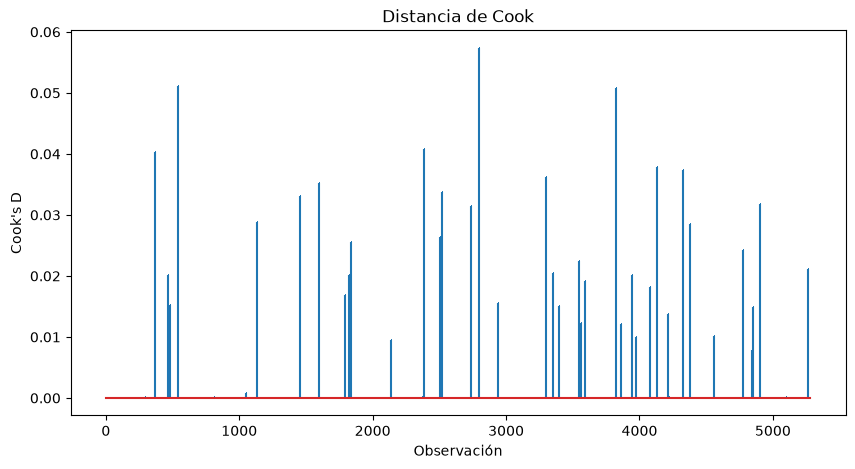

Observaciones influyentes (Cook's D > 4/n): [ 366  468  479  538 1048 1130 1456 1600 1795 1819 1838 2141 2388 2501
 2521 2740 2797 2941 3302 3350 3399 3550 3558 3595 3824 3864 3942 3975
 4077 4128 4213 4327 4377 4560 4779 4847 4852 4905 5263]


In [50]:
# Distancia de Cook
cooks = influence.cooks_distance[0]
plt.figure(figsize=(10, 5))
plt.stem(np.arange(len(cooks)), cooks, markerfmt=",")
plt.xlabel('Observación')
plt.ylabel("Cook's D")
plt.title("Distancia de Cook")
plt.show()

# Umbral general: 4/n
umbral_cook = 4 / n
influyentes = np.where(cooks > umbral_cook)[0]
print(f"Observaciones influyentes (Cook's D > 4/n): {influyentes}")

#### 1.2.6 Colinealidad

In [51]:
# VIF (Factor de Inflación de Varianza)
vif_data = pd.DataFrame()
vif_data["feature"] = X_train_df.columns
vif_data["VIF"] = [variance_inflation_factor(X_train_df.values, i)
                   for i in range(X_train_df.shape[1])]
print(vif_data.sort_values('VIF', ascending=False))

                            feature       VIF
15             bin__Internet_Access  8.344209
10             ord__Teacher_Quality  4.410450
7          ord__Access_to_Resources  3.232763
13              ord__Peer_Influence  3.232372
6         ord__Parental_Involvement  3.228069
8             ord__Motivation_Level  2.591776
14  bin__Extracurricular_Activities  2.366728
18                      bin__Gender  2.301970
9                ord__Family_Income  2.054087
11    ord__Parental_Education_Level  1.761414
12          ord__Distance_from_Home  1.540030
16                 bin__School_Type  1.427957
17       bin__Learning_Disabilities  1.119385
3              num__Previous_Scores  1.004983
5            num__Physical_Activity  1.004777
1                   num__Attendance  1.003637
0                num__Hours_Studied  1.003024
4            num__Tutoring_Sessions  1.002428
2                  num__Sleep_Hours  1.002113


VIF > 10 indica colinealidad severa. VIF > 5 es moderada. Si hay colinealidad, Ridge y ElasticNet son las alternativas más estables.

#### 1.2.7 Eliminar outliers y puntos palanca (solo los de Cook, ya que los puntos palanca normales son muchos)

In [52]:
idx_eliminar = np.unique(np.concatenate([outliers, influyentes]))

X_train_filt = X_train_const.drop(X_train_const.index[idx_eliminar])
y_train_filt = y_train.drop(y_train.index[idx_eliminar])

In [53]:
model_filt = sm.OLS(y_train_filt, X_train_filt).fit()
print(model_filt.summary())

                            OLS Regression Results                            
Dep. Variable:             Exam_Score   R-squared:                       0.990
Model:                            OLS   Adj. R-squared:                  0.990
Method:                 Least Squares   F-statistic:                 2.826e+04
Date:                Sun, 20 Sep 2026   Prob (F-statistic):               0.00
Time:                        22:22:39   Log-Likelihood:                -1634.4
No. Observations:                5243   AIC:                             3309.
Df Residuals:                    5223   BIC:                             3440.
Df Model:                          19                                         
Covariance Type:            nonrobust                                         
                                      coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------------------
const     

### 1.3 Ajuste de modelos con comparaciones de R2

In [54]:
# Ajustar OLS
pipeline_base.fit(X_train, y_train)

# Ajustar Ridge con GridSearch
grid_ridge = GridSearchCV(
    pipeline_ridge,
    {'model__alpha': np.logspace(-3, 3, 50)},
    cv=5, scoring='r2', n_jobs=-1
)
grid_ridge.fit(X_train, y_train)
best_ridge = grid_ridge.best_estimator_

# Ajustar Lasso con GridSearch
grid_lasso = GridSearchCV(
    pipeline_lasso,
    {'model__alpha': np.logspace(-3, 1, 50)},
    cv=5, scoring='r2', n_jobs=-1
)
grid_lasso.fit(X_train, y_train)
best_lasso = grid_lasso.best_estimator_

# Ajustar ElasticNet con GridSearch
grid_enet = GridSearchCV(
    pipeline_enet,
    {'model__alpha': np.logspace(-3, 1, 20),
     'model__l1_ratio': np.linspace(0.1, 0.9, 9)},
    cv=5, scoring='r2', n_jobs=-1
)
grid_enet.fit(X_train, y_train)
best_enet = grid_enet.best_estimator_

#Dataframe para comparar
modelos = {
    'OLS': pipeline_base,
    'Ridge': best_ridge,
    'Lasso': best_lasso,
    'ElasticNet': best_enet
}

filas = []
for nombre, modelo in modelos.items():
    y_train_pred = modelo.predict(X_train)
    y_test_pred = modelo.predict(X_test)
    filas.append({
        'Modelo': nombre,
        'R2_train': r2_score(y_train, y_train_pred),
        'R2_test': r2_score(y_test, y_test_pred),
        'RMSE_train': np.sqrt(mean_squared_error(y_train, y_train_pred)),
        'RMSE_test': np.sqrt(mean_squared_error(y_test, y_test_pred))
    })

df_resultados = pd.DataFrame(filas).set_index('Modelo')
print(df_resultados.round(4))

            R2_train  R2_test  RMSE_train  RMSE_test
Modelo                                              
OLS           0.7457   0.6700      1.9501     2.2268
Ridge         0.7457   0.6703      1.9501     2.2258
Lasso         0.7456   0.6707      1.9502     2.2242
ElasticNet    0.7456   0.6706      1.9502     2.2247


In [55]:

from IPython.display import display, HTML
from sklearn import set_config

set_config(display='diagram')

display(HTML("<h3>OLS (ajustado)</h3>"))
display(pipeline_base)

display(HTML("<h3>Ridge (ajustado)</h3>"))
display(best_ridge)

display(HTML("<h3>Lasso (ajustado)</h3>"))
display(best_lasso)

display(HTML("<h3>ElasticNet (ajustado)</h3>"))
display(best_enet)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](19,)","['Hours_Studied','Attendance','Parental_Involvement',..., 'Parental_Education_Level','Distance_from_Home','Gender']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,19
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('ord', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be aut

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](19,)","['Hours_Studied','Attendance','Parental_Involvement',..., 'Parental_Education_Level','Distance_from_Home','Gender']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,19
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('ord', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be aut

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](19,)","['Hours_Studied','Attendance','Parental_Involvement',..., 'Parental_Education_Level','Distance_from_Home','Gender']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,19
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('ord', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be aut

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](19,)","['Hours_Studied','Attendance','Parental_Involvement',..., 'Parental_Education_Level','Distance_from_Home','Gender']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,19
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('ord', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be aut

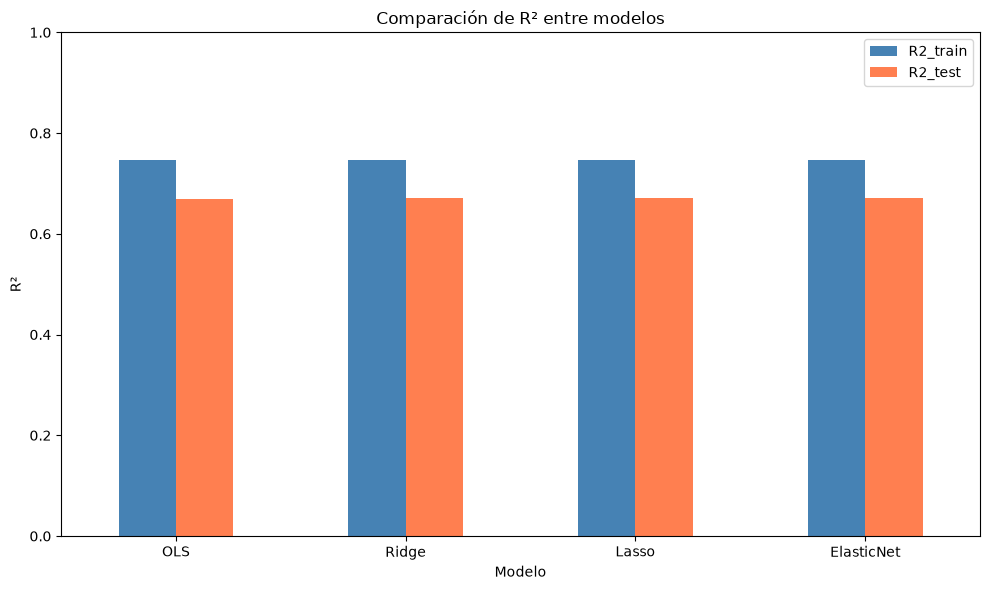

In [56]:
df_resultados[['R2_train', 'R2_test']].plot(kind='bar', figsize=(10, 6), color=['steelblue', 'coral'])
plt.title('Comparación de R² entre modelos')
plt.ylabel('R²')
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

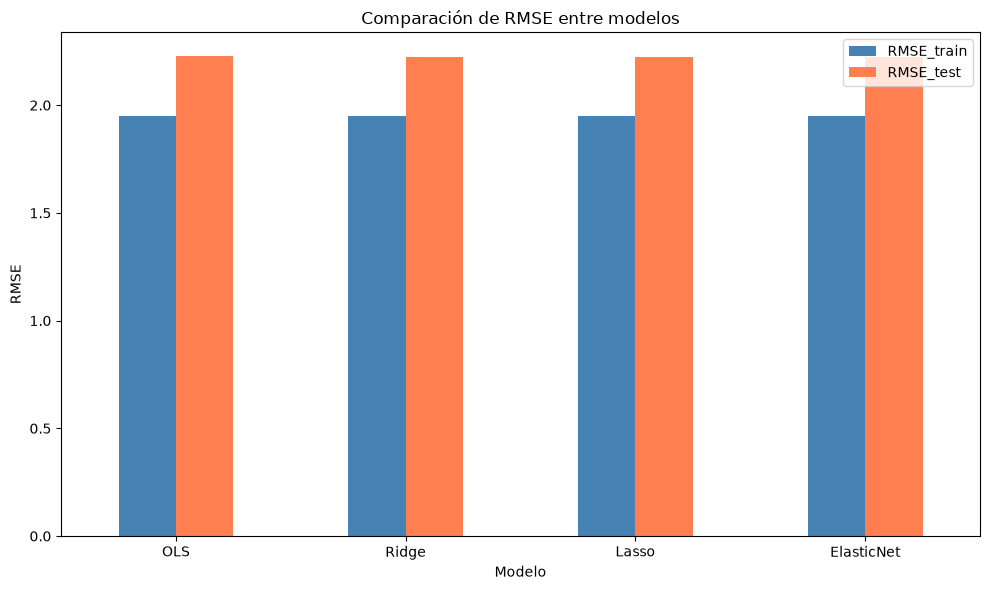

In [57]:
df_resultados[['RMSE_train', 'RMSE_test']].plot(kind='bar', figsize=(10, 6), color=['steelblue', 'coral'])
plt.title('Comparación de RMSE entre modelos')
plt.ylabel('RMSE')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

### 1.3.1 Observaciones de interés

No hay sobreajuste severo. Si lo hubiera, Ridge/Lasso/ElasticNet reducirían la brecha train-test. No lo hacen, así que el OLS ya está bien.
No hay colinealidad problemática. Si la hubiera, Ridge y ElasticNet mejorarían notablemente al OLS. No lo hacen.
El alpha óptimo probablemente sea muy pequeño. GridSearchCV seguramente eligió valores cercanos a 0, lo que equivale a "no penalizar". Eso confirma que la penalización no ayuda para este modelo inicial.

El modelo lineal sin interacciones es suficiente para este dataset. Los modelos polinomial y con interacciones desarrollados en la siguiente sección buscarán mejorar esto, de no ser así, la conclusión general será que la relación es esencialmente lineal.

### 1.4 Análisis de significancia de factores (modelo lineal sin penalización)

Se ajustó una regresión lineal múltiple por mínimos cuadrados ordinarios (OLS) sobre el conjunto de entrenamiento, tras eliminar las observaciones identificadas como outliers y puntos influyentes según la distancia de Cook.

**Factores significativos (p < 0.05):** 17 de 19 factores resultaron significativos. Los de mayor magnitud positiva son `Attendance` (+2.32), `Hours_Studied` (+1.79), `Internet_Access` (+1.01) y `Access_to_Resources` (+1.00). Los de mayor magnitud negativa son `Learning_Disabilities` (−1.03) y `Distance_from_Home` (−0.50).

**Factores no significativos (p ≥ 0.05):** `School_Type` (p = 0.783) y `Gender` (p = 0.481) no mostraron evidencia de asociación con `Exam_Score` al 5% de significancia, controlando por los demás factores del modelo.

Sobre `Sleep_Hours` aunque resultó significativo (p < 0.001), su coeficiente es prácticamente nulo (+0.0236). Esto es porque la significancia estadística no implica relevancia práctica, especialmente con tamaños de muestra grandes.

**Prueba F global:** El estadístico F del modelo es altamente significativo (p < 0.001), lo que indica que al menos uno de los coeficientes de pendiente es distinto de cero. El modelo en su conjunto explica una proporción considerable de la variabilidad de `Exam_Score`.

Las magnitudes de los coeficientes presentan valores uniformes (±0.5, ±1.0) y errores estándar extremadamente pequeños, esto se debe a que el dataset es sintético.

## Modelo con interacciones

### Justificación

Se propone un tercer modelo que incorpora interacciones justificadas entre factores académicos y de contexto, manteniendo los efectos principales originales (principio jerárquico). Las interacciones seleccionadas son:

- `Hours_Studied × Tutoring_Sessions`: el efecto de las horas de estudio podría depender de las sesiones de tutoría recibidas.
- `Hours_Studied × Access_to_Resources`: estudiar puede rendir más cuando hay buen acceso a recursos educativos.
- `Attendance × Parental_Involvement`: el efecto de la asistencia sobre la calificación podría variar según la participación de los padres.
- `Previous_Scores × Motivation_Level`: el desempeño previo podría pesar de forma distinta según el nivel de motivación actual.

Se mantiene el mismo esquema de preprocesamiento y las mismas cuatro versiones (OLS, Ridge, Lasso, ElasticNet) que en el modelo inicial, para que la comparación sea consistente.

In [58]:
df_int = df.copy()

nivel_map = {'Low': 0, 'Medium': 1, 'High': 2}
df_int['Access_num'] = df_int['Access_to_Resources'].map(nivel_map)
df_int['Motivation_num'] = df_int['Motivation_Level'].map(nivel_map)
df_int['Parental_num'] = df_int['Parental_Involvement'].map(nivel_map)

df_int['Hours_x_Tutoring'] = df_int['Hours_Studied'] * df_int['Tutoring_Sessions']
df_int['Hours_x_Access'] = df_int['Hours_Studied'] * df_int['Access_num']
df_int['Attendance_x_Parental'] = df_int['Attendance'] * df_int['Parental_num']
df_int['PrevScores_x_Motivation'] = df_int['Previous_Scores'] * df_int['Motivation_num']

df_int = df_int.drop(columns=['Access_num', 'Motivation_num', 'Parental_num'])

In [59]:
num_cols_int = num_cols + ['Hours_x_Tutoring', 'Hours_x_Access', 'Attendance_x_Parental', 'PrevScores_x_Motivation']

numerical_transformer_int = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

ordinal_transformer_int = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OrdinalEncoder(categories=ordinal_categories,
                               handle_unknown='use_encoded_value',
                               unknown_value=-1))
])

binary_transformer_int = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OrdinalEncoder(categories=binary_categories,
                               handle_unknown='use_encoded_value',
                               unknown_value=-1))
])

preprocessor_int = ColumnTransformer(
    transformers=[
        ('num', numerical_transformer_int, num_cols_int),
        ('ord', ordinal_transformer_int, ord_cols),
        ('bin', binary_transformer_int, bin_cols)
    ],
    remainder='drop'
)

pipeline_base_int = Pipeline(steps=[('preprocessor', preprocessor_int), ('model', LinearRegression())])
pipeline_ridge_int = Pipeline(steps=[('preprocessor', preprocessor_int), ('model', Ridge(random_state=42))])
pipeline_lasso_int = Pipeline(steps=[('preprocessor', preprocessor_int), ('model', Lasso(random_state=42, max_iter=10000))])
pipeline_enet_int = Pipeline(steps=[('preprocessor', preprocessor_int), ('model', ElasticNet(random_state=42, max_iter=10000))])

In [60]:
X_int = df_int.drop(columns=target_col)
y_int = df_int[target_col]

X_train_int, X_test_int, y_train_int, y_test_int = train_test_split(
    X_int, y_int, test_size=0.2, random_state=42
)

pipeline_base_int.fit(X_train_int, y_train_int)

grid_ridge_int = GridSearchCV(pipeline_ridge_int, {'model__alpha': np.logspace(-3, 3, 50)}, cv=5, scoring='r2', n_jobs=-1)
grid_ridge_int.fit(X_train_int, y_train_int)
best_ridge_int = grid_ridge_int.best_estimator_

grid_lasso_int = GridSearchCV(pipeline_lasso_int, {'model__alpha': np.logspace(-3, 1, 50)}, cv=5, scoring='r2', n_jobs=-1)
grid_lasso_int.fit(X_train_int, y_train_int)
best_lasso_int = grid_lasso_int.best_estimator_

grid_enet_int = GridSearchCV(pipeline_enet_int, {'model__alpha': np.logspace(-3, 1, 20), 'model__l1_ratio': np.linspace(0.1, 0.9, 9)}, cv=5, scoring='r2', n_jobs=-1)
grid_enet_int.fit(X_train_int, y_train_int)
best_enet_int = grid_enet_int.best_estimator_

modelos_int = {
    'OLS_interacciones': pipeline_base_int,
    'Ridge_interacciones': best_ridge_int,
    'Lasso_interacciones': best_lasso_int,
    'ElasticNet_interacciones': best_enet_int
}

filas_int = []
for nombre, modelo in modelos_int.items():
    y_train_pred = modelo.predict(X_train_int)
    y_test_pred = modelo.predict(X_test_int)
    filas_int.append({
        'Modelo': nombre,
        'R2_train': r2_score(y_train_int, y_train_pred),
        'R2_test': r2_score(y_test_int, y_test_pred),
        'RMSE_train': np.sqrt(mean_squared_error(y_train_int, y_train_pred)),
        'RMSE_test': np.sqrt(mean_squared_error(y_test_int, y_test_pred))
    })

df_resultados_int = pd.DataFrame(filas_int).set_index('Modelo')
print(df_resultados_int.round(4))

                          R2_train  R2_test  RMSE_train  RMSE_test
Modelo                                                            
OLS_interacciones           0.7459   0.6701      1.9492     2.2265
Ridge_interacciones         0.7459   0.6701      1.9492     2.2265
Lasso_interacciones         0.7458   0.6703      1.9494     2.2258
ElasticNet_interacciones    0.7458   0.6703      1.9494     2.2258


## Referencias


- James, G., Witten, D., Hastie, T., Tibshirani, R. y Taylor, J. (2023). *An Introduction to Statistical Learning: with Applications in Python*. Springer. Capítulos 3, 6 y 7.
- Laboratorio de regresión 1. Regresión lineal simple, residuos, RSS, RSE y $R^2$.
- Laboratorio de regresión 2. Significancia de factores, errores estándar, pruebas de hipótesis, *p-values*, regresión múltiple e interacciones.
- Laboratorio de regresión 3. Exploración, limpieza y validación de factores del conjunto de datos.
- Laboratorio de regresión 4. Modelos penalizados, Ridge, Lasso, selección de $\alpha$ y comparación de desempeño.
- Zou, H. y Hastie, T. (2005). “Regularization and Variable Selection via the Elastic Net”. *Journal of the Royal Statistical Society: Series B*, 67(2), 301-320.